In [18]:
import os
import numpy as np
import csv
from matplotlib import pyplot as plt
import pandas as pd
import itertools

ueNum = 4
scheds = ["RR", "PF", "MR", "Qos", "DPPA"]#, "Ai"]
num_sim = 1
gfbr_vr = 5  # Mbps
gfbr_cg = 10  # Mbps
bws = [10e6, 20e6, 40e6]  # Hz

# Average throughput

In [19]:
# sim_id = 0
# files = []
# # all_thput = []
# for sched in scheds:
#         print(f"-- Scheduler: {sched}")
#         files = []
#         for i in range (ueNum):
#                 files.append(f'ns-3-dev/sim_results/thput_avg_window_id{i+1}_{sched}.csv')
#         thput = []
#         x = np.arange(ueNum) + 1
#         space = np.linspace(-0.1*np.floor(len(files)/2), 0.1*np.floor(len(files)/2), len(files))
#         for f in files:
#                 for n in range(1,num_sim+1):
#                         thput_ue = []
#                         with open(f) as File:
#                                 reader = csv.reader(File, delimiter='\t', quotechar=',',
#                                                         quoting=csv.QUOTE_MINIMAL)
#                                 # Si el fichero esta vacio pintar 0
#                                 if os.stat(f).st_size == 0:
#                                         thput_ue.append(0)
#                                         break
#                                 next(reader)  # Skip header row
#                                 for row in reader:
#                                         thput_ue.append(float(row[1]))
#                 thput.append(np.array(thput_ue)) 
#         # thput = thput[::-1] # Check if reverse the array because the order of the scenario is reversed in the simulator code
#         # print(f"thput = {thput} Mbps")

#         # all_thput.append(thput)

#         # Plot
#         # plt.figure()
#         # print(f"thput = {thput} Mbps")
#         # for i, th in enumerate(thput):
#         #         plt.plot(2*np.arange(len(th)), th, label=f"UE{i+1}", marker='o')
#         # plt.ylabel("Av. throughput [Mbps]")
#         # plt.xlabel("Time (s)")
#         # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#         # plt.grid(axis='y')
#         # plt.title(f'{sched}')

#         # Boxplot
#         # Quito el último valor
#         thput = [np.array(t[:-1]) for t in thput]
#         plt.figure()
#         plt.boxplot(thput, positions=x,
#                    showmeans=True, 
#                    meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 7})
#         plt.ylabel("Av. throughput [Mbps]")
#         plt.xlabel("UE ID")
#         plt.grid(axis='y')
#         # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#         plt.title(f'{sched}')
#         # Linea horizontal en GFBR
#         plt.axhline(y=gfbr_vr, color='k', linestyle='--', label='GFBR')
#         plt.axhline(y=gfbr_cg, color='k', linestyle='--', label='GFBR')

# # print(f"all_thput = {all_thput} Mbps")

# Comparación de todos los schedulers (Boxplots combinados)

-- Recopilando datos para scheduler: RR
-- Recopilando datos para scheduler: PF
-- Recopilando datos para scheduler: MR
-- Recopilando datos para scheduler: Qos
-- Recopilando datos para scheduler: DPPA


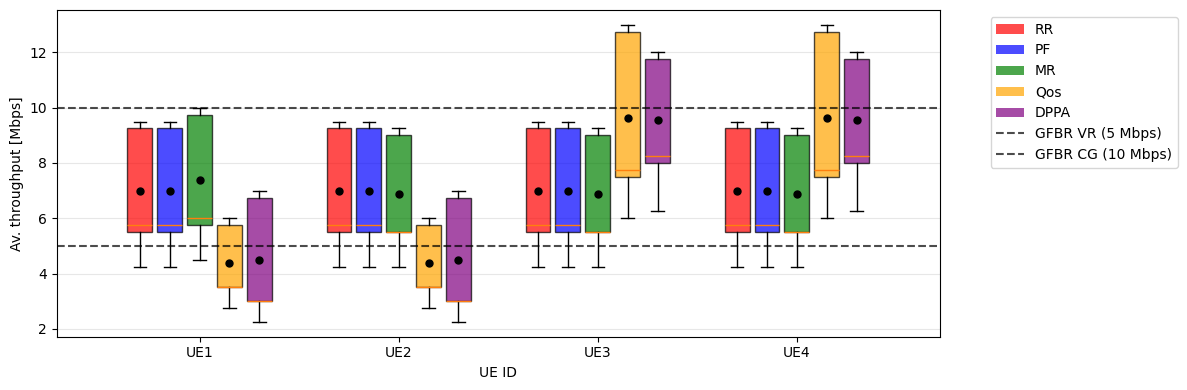

-- Recopilando datos para scheduler: RR
-- Recopilando datos para scheduler: PF
-- Recopilando datos para scheduler: MR
-- Recopilando datos para scheduler: Qos
-- Recopilando datos para scheduler: DPPA


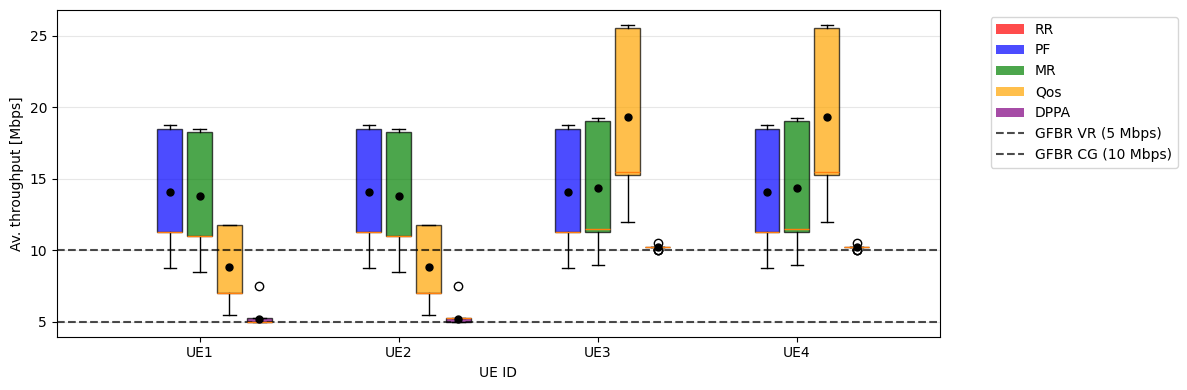

-- Recopilando datos para scheduler: RR
-- Recopilando datos para scheduler: PF
-- Recopilando datos para scheduler: MR
-- Recopilando datos para scheduler: Qos
-- Recopilando datos para scheduler: DPPA


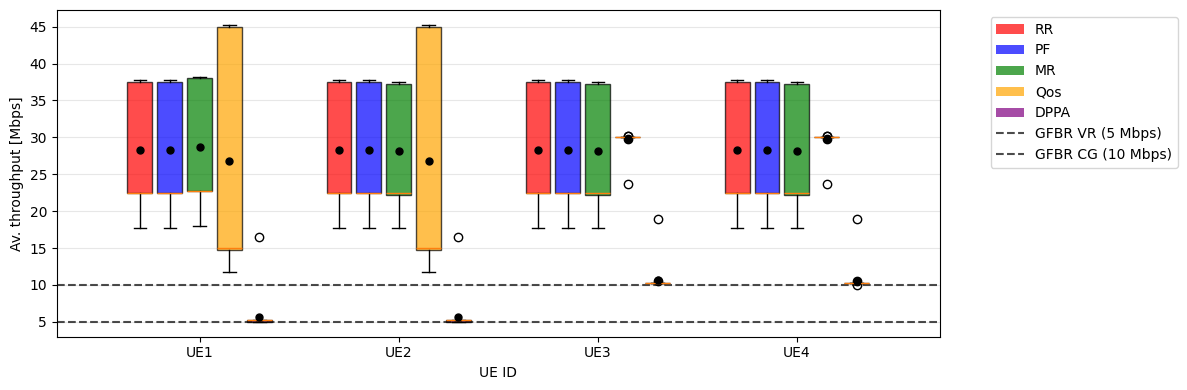

In [20]:
for bw in bws:
    # Recopilar datos de throughput para todos los schedulers
    all_thput_data = {}
    colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colores para cada scheduler

    for sched in scheds:
        print(f"-- Recopilando datos para scheduler: {sched}")
        files = []
        for i in range(ueNum):
            files.append(f'ns-3-dev/sim_results/thput_avg_window_id{i+1}_{sched}_{bw}.csv')
        
        thput = []
        for f in files:
            thput_ue = []
            with open(f) as File:
                reader = csv.reader(File, delimiter='\t', quotechar=',',
                                quoting=csv.QUOTE_MINIMAL)
                # Si el fichero esta vacio pintar 0
                if os.stat(f).st_size == 0:
                    thput_ue.append(0)
                else:
                    next(reader)  # Skip header row
                    for row in reader:
                        thput_ue.append(float(row[1]))
            thput.append(np.array(thput_ue))
        
        # Quitar el último valor como en el código original
        thput = [np.array(t[:-1]) for t in thput]
        all_thput_data[sched] = thput

    # Crear la figura combinada
    plt.figure(figsize=(12, 4))

    # Configuración para posicionamiento de boxplots
    ue_positions = np.arange(1, ueNum + 1) * 1.2  # Posiciones base para cada UE (más separadas)
    box_width = 0.15  # Ancho de cada boxplot
    spacing = 0.18   # Espaciado entre boxplots

    # Crear offsets para cada scheduler
    n_scheds = len(scheds)
    offsets = np.linspace(-(n_scheds-1)*spacing/2, (n_scheds-1)*spacing/2, n_scheds)

    # Plot para cada scheduler
    for i, sched in enumerate(scheds):
        for ue_idx in range(ueNum):
            # Posición del boxplot para este UE y scheduler
            position = ue_positions[ue_idx] + offsets[i]
            
            # Crear boxplot
            bp = plt.boxplot(all_thput_data[sched][ue_idx], 
                            positions=[position],
                            widths=box_width,
                            showmeans=True,
                            meanprops={"marker": "o", "markerfacecolor": "black", 
                                    "markeredgecolor": "black", "markersize": 5},
                            patch_artist=True)  # Necesario para colorear las cajas
            
            # Colorear la caja
            bp['boxes'][0].set_facecolor(colors[i])
            bp['boxes'][0].set_alpha(0.7)

    # Configuración de la figura
    plt.ylabel("Av. throughput [Mbps]")
    plt.xlabel("UE ID")
    # plt.title("Comparación de Throughput por UE y Scheduler")
    plt.grid(axis='y', alpha=0.3)

    # Configurar xticks
    plt.xticks(ue_positions, [f'UE{i}' for i in range(1, ueNum + 1)])

    # Añadir líneas horizontales para GFBR
    plt.axhline(y=gfbr_vr, color='k', linestyle='--', alpha=0.7, label=f'GFBR VR ({gfbr_vr} Mbps)')
    plt.axhline(y=gfbr_cg, color='k', linestyle='--', alpha=0.7, label=f'GFBR CG ({gfbr_cg} Mbps)')

    # Crear leyenda personalizada
    legend_elements = []
    for i, sched in enumerate(scheds):
        legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, label=sched))
    legend_elements.append(plt.Line2D([0], [0], color='k', linestyle='--', alpha=0.7, label=f'GFBR VR ({gfbr_vr} Mbps)'))
    legend_elements.append(plt.Line2D([0], [0], color='k', linestyle='--', alpha=0.7, label=f'GFBR CG ({gfbr_cg} Mbps)'))

    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Resources usage

In [26]:
for sched in scheds:
        files = [f'ns-3-dev/sim_results/alpha_{sched}.csv']

        for i, file in enumerate(files):
                df = pd.read_csv(file, sep='\t')

        plt.figure()
        space = np.linspace(-((6-1)/2)*0.1, ((6-1)/2)*0.1, 6)
        # for i in range(ueNum,0,-1):
        for i in range(1,ueNum+1):
                rbgs_slot = (df[df['ue'] == i]['resources'])
                # Quitar los primeros slots
                # rbgs_slot = rbgs_slot[107:]
                # TODO meter 0s al UE que no tiene datos en un slot
                # Obtener el tamaño del array
                size = rbgs_slot.size
                # Calcular cuántos elementos sobran para que el tamaño sea un múltiplo de 10
                remainder = int(size % 2000)
                # print(f'remainder UE{i} - {sched}: {remainder}')
                # Si hay elementos que sobran, los elimina
                print(f'UE{i} - {sched}: {rbgs_slot}')
                print(f'len UE{i} - {sched}: {len(rbgs_slot)}')
                if remainder != 0:
                        rbgs_slot = rbgs_slot[:-remainder]
                print(f'len UE{i} - {sched}: {len(rbgs_slot)}')
                rbgs_slot_mean_1 = np.mean(np.reshape(rbgs_slot, (-1, 2000)), axis=1)
                # plt.plot(2*np.arange(len(rbgs_slot_mean_1)), rbgs_slot_mean_1, marker='o')
                plt.title(f"{sched}")
                plt.boxplot(rbgs_slot_mean_1, positions=[i + space[i-1]],
                           widths=0.1,
                           showmeans=True, 
                           meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 7})
        # plt.ylabel("Av. RBs")
        plt.ylabel("RBs")
        # plt.xlabel("Time (s)")
        labels = []
        plt.legend([f"UE{i+1}" for i in range(ueNum)], bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(axis='y')
        # plt.xticks(2*np.arange(len(rbgs_slot_mean_1)));
        plt.xticks([])

FileNotFoundError: [Errno 2] No such file or directory: 'ns-3-dev/sim_results/alpha_RR.csv'

In [22]:
# # Checkear si está bien. Es lo mismo, pero rellenando con 0s los slots que no tienen datos para un UE
# for sched in scheds:
#     files = [f'ns-3-dev/sim_results/alpha_{sched}.csv']

#     for i, file in enumerate(files):
#         df = pd.read_csv(file, sep='\t')

#     plt.figure()
#     space = np.linspace(-((6-1)/2)*0.1, ((6-1)/2)*0.1, 6)
    
#     for ue_id in range(1, ueNum + 1):
#         # SOLUCIÓN: Crear un DataFrame completo para cada UE
#         # 1. Obtener todos los tiempos únicos del archivo
#         all_times = sorted(df['time'].unique())
        
#         # 2. Crear DataFrame con todos los tiempos para este UE
#         complete_times = pd.DataFrame({'time': all_times})
        
#         # 3. Obtener datos reales del UE
#         ue_data = df[df['ue'] == ue_id][['time', 'resources']]
        
#         # 4. Hacer merge y rellenar con 0s donde no hay datos
#         complete_ue_data = complete_times.merge(ue_data, on='time', how='left')
#         complete_ue_data['resources'] = complete_ue_data['resources'].fillna(0)
        
#         # 5. Extraer los recursos ya completos con 0s
#         rbgs_slot = complete_ue_data['resources'].values
        
#         # Quitar los primeros slots si es necesario
#         # rbgs_slot = rbgs_slot[107:]
        
#         # Obtener el tamaño del array
#         size = rbgs_slot.size
#         # Calcular cuántos elementos sobran para que el tamaño sea un múltiplo de 2000
#         remainder = int(size % 2000)
#         # print(f'remainder UE{ue_id} - {sched}: {remainder}')
#         # Si hay elementos que sobran, los elimina
#         if remainder != 0:
#             rbgs_slot = rbgs_slot[:-remainder]
        
#         rbgs_slot_mean_1 = np.mean(np.reshape(rbgs_slot, (-1, 2000)), axis=1)
        
#         plt.title(f"{sched}")
#         plt.boxplot(rbgs_slot_mean_1, positions=[ue_id + space[ue_id-1]],
#                    widths=0.1,
#                    showmeans=True, 
#                    meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 7})
    
#     plt.ylabel("RBs")
#     labels = []
#     plt.legend([f"UE{i+1}" for i in range(ueNum)], bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.grid(axis='y')
#     plt.xticks([])
#     plt.ylim([0, rbgs_slot_mean_1.max()*1.2])

In [23]:
# for bw in bws:
#     # Calcular el total de recursos usados por cada scheduler
#     total_rbs = []
#     for sched in scheds:
#         file = f'ns-3-dev/sim_results/alpha_{sched}_{bw}.csv'
#         df = pd.read_csv(file, sep='\t')
#         total_rbs.append(df['resources'].sum())

#     print(f'Total RBs usados por scheduler: {dict(zip(scheds, total_rbs))}')

#     # Graficar el total de recursos por scheduler
#     # plt.figure(figsize=(8, 5))
#     # plt.bar(scheds, total_rbs, color='skyblue')
#     # plt.ylabel("Total RBs usados")
#     # plt.xlabel("Scheduler")
#     # plt.title("Total de recursos (RBs) usados por Scheduler")
#     # plt.grid(axis='y', alpha=0.3)
#     # plt.tight_layout()
#     # plt.show()

#     # Ahora en porcentajes respecto al total de RBs disponibles
#     # Asumiendo el máximo de RBs el del scheduler que más ha usado
#     max_rbs = max(total_rbs)
#     total_rbs_percentage = [(rbs / max_rbs) * 100 for rbs in total_rbs]
#     print(f'Total RBs usados por scheduler (%): {dict(zip(scheds, total_rbs_percentage))}')
#     plt.figure(figsize=(8, 5))
#     plt.bar(scheds, total_rbs_percentage, color='lightgreen')
#     plt.ylabel("Total RBs usados (%)")
#     plt.xlabel("Scheduler")
#     plt.title("Total de recursos (RBs) usados por Scheduler (%)")
#     plt.ylim(0, 110)
#     plt.grid(axis='y', alpha=0.3)
#     plt.tight_layout()
#     plt.show()

BW 10 MHz - Total RBs: {'RR': np.int64(32933652), 'PF': np.int64(32933652), 'MR': np.int64(32933652), 'Qos': np.int64(32933652), 'DPPA': np.int64(32933630)}
BW 20 MHz - Total RBs: {'RR': np.int64(65867216), 'PF': np.int64(65867216), 'MR': np.int64(65867216), 'Qos': np.int64(65867216), 'DPPA': np.int64(38883516)}
BW 20 MHz - Total RBs: {'RR': np.int64(65867216), 'PF': np.int64(65867216), 'MR': np.int64(65867216), 'Qos': np.int64(65867216), 'DPPA': np.int64(38883516)}
BW 40 MHz - Total RBs: {'RR': np.int64(132355732), 'PF': np.int64(132355732), 'MR': np.int64(132355732), 'Qos': np.int64(132355732), 'DPPA': np.int64(41001714)}
BW 40 MHz - Total RBs: {'RR': np.int64(132355732), 'PF': np.int64(132355732), 'MR': np.int64(132355732), 'Qos': np.int64(132355732), 'DPPA': np.int64(41001714)}


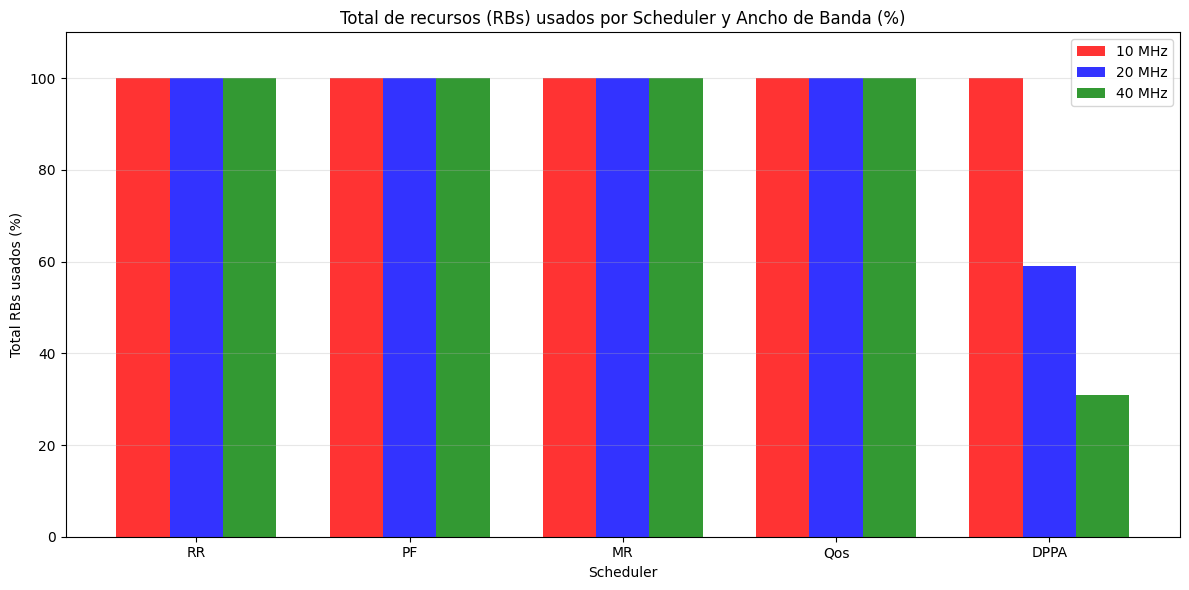


Tabla resumen (% respecto al máximo de cada BW):
Scheduler	10 MHz	20 MHz	40 MHz
----------------------------------------
RR		100.0%	100.0%	100.0%
PF		100.0%	100.0%	100.0%
MR		100.0%	100.0%	100.0%
Qos		100.0%	100.0%	100.0%
DPPA		100.0%	59.0%	31.0%


In [24]:
# Recopilar datos de todos los anchos de banda
all_data = {}
bw_labels = ['10 MHz', '20 MHz', '40 MHz']

for i, bw in enumerate(bws):
    # Calcular el total de recursos usados por cada scheduler
    total_rbs = []
    for sched in scheds:
        file = f'ns-3-dev/sim_results/alpha_{sched}_{bw}.csv'
        df = pd.read_csv(file, sep='\t')
        total_rbs.append(df['resources'].sum())
    
    print(f'BW {bw/1e6:.0f} MHz - Total RBs: {dict(zip(scheds, total_rbs))}')
    
    # Calcular porcentajes respecto al máximo de este ancho de banda
    max_rbs = max(total_rbs)
    total_rbs_percentage = [(rbs / max_rbs) * 100 for rbs in total_rbs]
    
    # Almacenar datos para cada scheduler
    for j, sched in enumerate(scheds):
        if sched not in all_data:
            all_data[sched] = []
        all_data[sched].append(total_rbs_percentage[j])

# Crear la figura combinada
plt.figure(figsize=(12, 6))

# Configuración para el agrupamiento de barras
x_pos = np.arange(len(scheds))  # Posiciones base para cada scheduler
bar_width = 0.25  # Ancho de cada barra
# colors = ['lightcoral', 'lightblue', 'lightgreen']  # Colores para cada BW

# Crear las barras agrupadas
for i, bw_label in enumerate(bw_labels):
    # Calcular posición de cada grupo de barras
    positions = x_pos + (i - 1) * bar_width  # Centrar las barras
    
    # Obtener los datos para este ancho de banda
    values = [all_data[sched][i] for sched in scheds]
    
    # Crear las barras
    plt.bar(positions, values, bar_width, 
           label=bw_label, color=colors[i], alpha=0.8)

# Configuración de la figura
plt.ylabel("Total RBs usados (%)")
plt.xlabel("Scheduler")
plt.title("Total de recursos (RBs) usados por Scheduler y Ancho de Banda (%)")
plt.xticks(x_pos, scheds)  # Etiquetas de los schedulers
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\nTabla resumen (% respecto al máximo de cada BW):")
print("Scheduler\t10 MHz\t20 MHz\t40 MHz")
print("-" * 40)
for sched in scheds:
    values = all_data[sched]
    print(f"{sched}\t\t{values[0]:.1f}%\t{values[1]:.1f}%\t{values[2]:.1f}%")

In [25]:
# ueNum = 1
# sim_id = 0
# files = []
# # all_thput = []
# for sched in ["DPPA"]:
#         print(f"-- Scheduler: {sched}")
#         files = []
#         for i in range (ueNum):
#                 files.append(f'ns-3-dev/sim_results/thput_avg_window_id{i+1}_{sched}.csv')
#         thput = []
#         x = np.arange(ueNum) + 1
#         space = np.linspace(-0.1*np.floor(len(files)/2), 0.1*np.floor(len(files)/2), len(files))
#         for f in files:
#                 for n in range(1,num_sim+1):
#                         thput_ue = []
#                         with open(f) as File:
#                                 reader = csv.reader(File, delimiter='\t', quotechar=',',
#                                                         quoting=csv.QUOTE_MINIMAL)
#                                 # Si el fichero esta vacio pintar 0
#                                 if os.stat(f).st_size == 0:
#                                         thput_ue.append(0)
#                                         break
#                                 next(reader)  # Skip header row
#                                 for row in reader:
#                                         thput_ue.append(float(row[1]))
#                 thput.append(np.array(thput_ue)) 
#         # thput = thput[::-1] # Check if reverse the array because the order of the scenario is reversed in the simulator code
#         # print(f"thput = {thput} Mbps")

#         # all_thput.append(thput)

#         # Plot
#         plt.figure()
#         # print(f"thput = {thput} Mbps")
#         for i, th in enumerate(thput):
#                 plt.plot(2*np.arange(len(th)), th, label=f"UE{i+1}", marker='o')
#         plt.ylabel("Av. throughput [Mbps]")
#         plt.xlabel("Time (s)")
#         plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#         plt.grid(axis='y')
#         plt.title(f'{sched}')
        

#         # Boxplot
#         # Quito el último valor
#         thput = [np.array(t[:-1]) for t in thput]
#         plt.figure()
#         plt.boxplot(thput, positions=x,
#                    showmeans=True, 
#                    meanprops={"marker": "o", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 7})
#         plt.ylabel("Av. throughput [Mbps]")
#         plt.xlabel("UE ID")
#         plt.grid(axis='y')
#         # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#         plt.title(f'{sched}')
#         # Linea horizontal en GFBR
#         plt.axhline(y=gfbr_vr, color='k', linestyle='--', label='GFBR')
#         plt.axhline(y=gfbr_cg, color='k', linestyle='--', label='GFBR')